# CUGRAPH

Este es un ejemplito de como leer un csv con los edges de un grafo, visualizarlo, y realizar operaciones en la gpu.

In [1]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


## Visualización del grafo y de la matriz de adyacencia

matriz de adjacencia:
 [[1. 1. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 1. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 1. 1. 0. 0. 0.]
 [1. 1. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]]
matriz de adjacencia a la 3:
 [[7. 6. 3. 3. 6. 1. 0. 0. 0.]
 [6. 3. 5. 1. 7. 2. 0. 0. 0.]
 [3. 5. 0. 5. 1. 0. 0. 0. 0.]
 [3. 1. 5. 0. 6. 3. 0. 0. 0.]
 [6. 7. 1. 6. 3. 0. 0. 0. 0.]
 [1. 2. 0. 3. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]]
no zeros de la matriz:  18
no zeros de la matriz^3:  32
traza(G^3) =  14.0


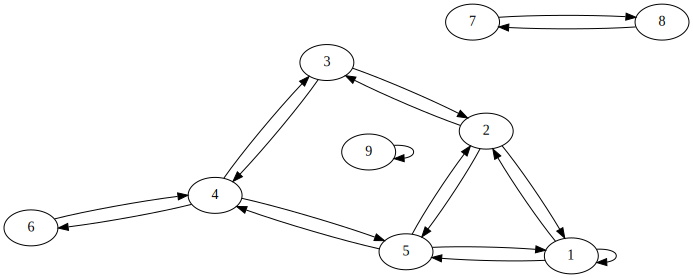

In [11]:
#########################################
# Echemosle un vistazo al grafo usando graphiz

import cugraph
import cudf
import cupy as cp
from graphviz import Digraph

# read data into a cuDF DataFrame using read_csv
#gdf = cudf.read_csv("graph_data.csv", names=["src", "dst"], dtype=["int32", "int32"])
gdf = cudf.read_csv("graph_data.csv")
dot = Digraph(comment='INPG2021',engine='sfdp')

gpa=gdf.to_pandas()

madj=cp.zeros((9,9))

for a, b in gpa.itertuples(index=False):
    dot.edge(str(a),str(b), constraint='false')
    madj[a-1,b-1]=1
    #print(a, b)


print("matriz de adjacencia:\n",madj)

madj3=cp.linalg.matrix_power(madj,3)
print("matriz de adjacencia a la 3:\n",madj3)

print("no zeros de la matriz: ",cp.flatnonzero(madj).size)
print("no zeros de la matriz^3: ",cp.flatnonzero(madj3).size)

print("traza(G^3) = ", cp.trace(madj3))

dot

##  CUGRAPH para obtener propiedades del grafo

In [12]:
import cugraph
import cudf

# read data into a cuDF DataFrame using read_csv
#gdf = cudf.read_csv("graph_data.csv", names=["src", "dst"], dtype=["int32", "int32"])
gdf = cudf.read_csv("graph_data.csv")

# pesos (necesarios para algunas cosas nomas)
gdf["data"] = 1.0


# We now have data as edge pairs
# create a Graph using the source (src) and destination (dst) vertex pairs
G = cugraph.Graph()
G.from_cudf_edgelist(gdf, source='src', destination='dst')

print("\n\n")



######################################
#https://es.wikipedia.org/wiki/PageRank
#
# PR(A) = (1-d)+d Sum_{i=1}^n PR(i)/C(i)
#
# A es el PageRank de la página A.
# d es un factor de amortiguación que tiene un valor entre 0 y 1.
# PR(i)son los valores de PageRank que tienen cada una de las páginas i que enlazan a A.
# C(i) es el número total de enlaces salientes de la página i (sean o no hacia A).

# Let's now get the PageRank score of each vertex by calling cugraph.pagerank
df_page = cugraph.pagerank(G)

# Let's look at the PageRank Score (only do this on small graphs)
for i in range(len(df_page)):
	print("vertex " + str(df_page['vertex'].iloc[i]) +
		" PageRank is " + str(df_page['pagerank'].iloc[i]))

print("\n\n")

#####################################
#https://en.wikipedia.org/wiki/Component_(graph_theory)

# Call cugraph.weakly_connected_components on the dataframe
df_cc = cugraph.weakly_connected_components(G)

# Use groupby on the 'labels' column of the WCC output to get the counts of each connected component label
label_gby = df_cc.groupby('labels')
label_count = label_gby.count()

print("Total number of components found : ", len(label_count))

# Call nlargest on the groupby result to get the row where the component count is the largest
largest_component = label_count.nlargest(n = 1, columns = 'vertex')
print("Size of the largest component is found to be : ", largest_component['vertex'].iloc[0])

smallest_component = label_count.nsmallest(n = 1, columns = 'vertex')
print("Size of the smallest component is found to be : ", smallest_component['vertex'].iloc[0])

#df_cc.head(20)

print("\n\n")

#############################################################
# https://en.wikipedia.org/wiki/Shortest_path_problem
# Call cugraph.sssp to get the distances from vertex 1:

df_ssp = cugraph.sssp(G, 1)

print("no todos los caminos conducen al nodo 1, y estos son los minimos:")

# Print the paths
for index, row in df_ssp.to_pandas().iterrows():
    v = int(row['vertex'])
    p = cugraph.utils.get_traversed_path_list(df_ssp, v)
    print(v, ': ', p)

print("\n\n")

##############################################################
# 
cu_count = cugraph.triangles(G)
print("numero de triangulos: ", cu_count)

print("\n\n")





vertex 4 PageRank is 0.13981377
vertex 1 PageRank is 0.12384827
vertex 6 PageRank is 0.05628124
vertex 8 PageRank is 0.11111111
vertex 2 PageRank is 0.12706584
vertex 5 PageRank is 0.12737396
vertex 3 PageRank is 0.09228361
vertex 9 PageRank is 0.11111111
vertex 7 PageRank is 0.11111111



Total number of components found :  3
Size of the largest component is found to be :  6
Size of the smallest component is found to be :  1



no todos los caminos conducen al nodo 1, y estos son los minimos:
4 :  [4, 5, 1]
6 :  [6, 4, 5, 1]
2 :  [2, 1]
5 :  [5, 1]
3 :  [3, 2, 1]
7 :  [7]
1 :  [1]
8 :  [8]
9 :  [9]



numero de triangulos:  5





## CUDF como pandas, pero en GPU

In [ ]:
import cudf
import io, requests

# download CSV file from GitHub
url="https://github.com/plotly/datasets/raw/master/tips.csv"
content = requests.get(url).content.decode('utf-8')

# read CSV from memory
tips_df = cudf.read_csv(io.StringIO(content))
tips_df['tip_percentage'] = tips_df['tip']/tips_df['total_bill']*100

# display average tip by dining party size
print(tips_df.groupby('size').tip_percentage.mean())